In [18]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from matplotlib import pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import itertools
import tensorflow as tf


# Example: Q_MAX river flow
q_min = pd.read_csv("q_min.csv")

# Optional: clean column names
q_min.columns = q_min.columns.str.strip().str.lower()


#def smooth_loss(y_true, y_pred):
#    mse = tf.reduce_mean(tf.square(y_true - y_pred))
#    smooth = tf.reduce_mean(tf.square(y_pred[1:] - y_pred[:-1]))
#    return mse + 0.05 * smooth

def smooth_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    penalty = tf.reduce_mean(tf.square(y_pred))
    return mse + 1e-6 * penalty

def nse(y_true, y_pred):
    """Nash-Sutcliffe Efficiency"""
    denom = np.sum((y_true - np.mean(y_true))**2)
    if denom == 0:
        return 0
    return 1 - np.sum((y_true - y_pred)**2) / denom

def prepare_time_series(df, value_name='flow'):
    months = ["jan","feb","mar","apr","maj","jun","jul","avg","sep","okt","nov","dec"]
    existing_months = [m for m in months if m in df.columns]

    # Convert to numeric and fill missing
    df[existing_months] = df[existing_months].apply(pd.to_numeric, errors='coerce')
    df[existing_months] = df[existing_months].fillna(method='ffill').fillna(method='bfill')

    # Melt to long format
    ts = df.melt(id_vars='year', value_vars=existing_months, var_name='month', value_name=value_name)
    ts['date'] = pd.to_datetime(ts['year'].astype(str) + '-' + ts['month'], format='%Y-%b', errors='coerce')
    ts = ts.dropna(subset=['date'])
    ts = ts.set_index('date').sort_index()
    ts = ts.dropna(subset=[value_name])
    
    # Ensure non-negative
    ts[value_name] = ts[value_name].clip(lower=0)
    
    return ts


def prepare_ml_data(ts, window_size=12, split_date='2014-01-01'):
    
    ts = ts.copy()
    ts['flow'] = ts['flow'].clip(lower=0)

    # Seasonal encoding
    ts['sin_month'] = np.sin(2 * np.pi * ts.index.month / 12)
    ts['cos_month'] = np.cos(2 * np.pi * ts.index.month / 12)


    #added 
    #ts['rolling_mean_3']  = ts['flow'].rolling(3).mean()
    #ts['rolling_mean_6']  = ts['flow'].rolling(6).mean()
    #ts['rolling_std_6']   = ts['flow'].rolling(6).std()
    #ts['lag_12'] = ts['flow'].shift(12)
    #ts['lag_24'] = ts['flow'].shift(24)
    ## end of adding features 

    flows = ts['flow'].values
    sin_m = ts['sin_month'].values
    cos_m = ts['cos_month'].values
    dates = ts.index

    X, y, idx = [], [], []
    for i in range(window_size, len(flows)):
        lag_vals = flows[i-window_size:i]
        features = np.concatenate([lag_vals, [sin_m[i], cos_m[i]]])
        
        X.append(features)
        y.append(flows[i])
        idx.append(dates[i])

    X = np.array(X)
    y = np.array(y)
    idx = pd.to_datetime(idx)

    # Log transform
    y_log = np.log1p(y)

    # Train/test split
    split_date = pd.to_datetime(split_date)
    split_idx = np.where(idx < split_date)[0]
    split = split_idx[-1] + 1 if len(split_idx) > 0 else 0

    return {
        "X_train": X[:split],
        "y_train": y_log[:split],
        "X_test": X[split:],
        "y_test": y[split:],        # original scale
        "idx_test": idx[split:]
    }


def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    nse = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    return rmse, mae, nse

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GRU, Dense, MaxPooling1D, Dropout
from tensorflow.keras.layers import Bidirectional, BatchNormalization

from tensorflow.keras import regularizers

import tensorflow as tf

# =====================================================
# NSE METRIC
# =====================================================

def nse_metric(y_true, y_pred):

    numerator = tf.reduce_sum(
        tf.square(y_true - y_pred)
    )

    denominator = tf.reduce_sum(
        tf.square(y_true - tf.reduce_mean(y_true))
    )

    return 1.0 - numerator / (denominator + 1e-8)


# =====================================================
# NSE LOSS
# (maximize NSE = minimize 1-NSE)
# =====================================================

def nse_loss(y_true, y_pred):

    numerator = tf.reduce_sum(
        tf.square(y_true - y_pred)
    )

    denominator = tf.reduce_sum(
        tf.square(y_true - tf.reduce_mean(y_true))
    )

    nse = 1.0 - numerator / (denominator + 1e-8)

    # minimize negative NSE
    return 1.0 - nse

def rmse_loss(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))

def build_cnn_gru(input_shape):

    model = Sequential([

        Conv1D(
            64,
            kernel_size=3,
            padding='same',
            activation='relu',
            kernel_regularizer=regularizers.l2(1e-4)
        ),

        MaxPooling1D(2),

        Dropout(0.1),

        GRU(
            64,
            return_sequences=False,
            dropout=0.2,
            recurrent_dropout=0.1,
            kernel_regularizer=regularizers.l2(1e-4)
        ),
        #Dense(32, activation='relu'), #added this ??
        Dropout(0.1),
        Dense(1)
    ])

    model.compile(
        optimizer='adam',
        #loss=rmse_loss,#nse_loss,
        loss = tf.keras.losses.Huber(), 
        metrics=[nse_metric]
    )

    return model


def build_cnn_gru1(input_shape):

    model = Sequential([

        Conv1D(
            filters=32,
            kernel_size=2,
            padding='same',
            activation='relu',
            kernel_regularizer=regularizers.l2(1e-4),
            input_shape=input_shape
        ),

        BatchNormalization(),

        MaxPooling1D(pool_size=2),

        Dropout(0.2),

        GRU(
            32,
            dropout=0.2,
            recurrent_dropout=0.2,
            return_sequences=False,
            kernel_regularizer=regularizers.l2(1e-4)
        ),

        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.Huber(),
        metrics=[nse_metric]
    )

    return model

In [20]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# TRAIN CNN-GRU
# =====================================================

def train_cnn_gru(X_train, y_train):

    tscv = TimeSeriesSplit(n_splits=5)
    scores = []

    for train_idx, val_idx in tscv.split(X_train):

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        # -----------------------------
        # SCALE
        # -----------------------------
        scaler = StandardScaler()

        X_tr = scaler.fit_transform(X_tr)
        X_val = scaler.transform(X_val)

        # reshape for CNN-GRU
        X_tr = X_tr.reshape((X_tr.shape[0], X_tr.shape[1], 1))
        X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

        # -----------------------------
        # BUILD MODEL
        # -----------------------------
        model = build_cnn_gru((X_tr.shape[1], 1))

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=30,
            min_delta=1e-4,
            restore_best_weights=True
        )

        # -----------------------------
        # TRAIN
        # -----------------------------
        model.fit(
            X_tr,
            y_tr,
            validation_data=(X_val, y_val),
            epochs=200,
            batch_size=32,
            verbose=0,
            callbacks=[early_stop]
        )

        # -----------------------------
        # VALIDATION NSE
        # -----------------------------
        y_pred = np.expm1(model.predict(X_val).flatten())
        y_true = np.expm1(y_val)

        score = nse(y_true, y_pred)

        scores.append(score)

    print("\nCNN-GRU CV NSE (mean):", np.mean(scores))

    # =====================================================
    # FINAL TRAIN ON FULL TRAINING SET
    # =====================================================

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X_train)

    X_scaled = X_scaled.reshape(
        (X_scaled.shape[0], X_scaled.shape[1], 1)
    )

    final_model = build_cnn_gru((X_scaled.shape[1], 1))

    early_stop = EarlyStopping(
        monitor='loss',
        patience=20,
        min_delta=1e-4,
        restore_best_weights=True
    )

    final_model.fit(
        X_scaled,
        y_train,
        epochs=200,
        batch_size=32,
        verbose=0,
        callbacks=[early_stop]
    )

    # =====================================================
    # TRAIN METRICS
    # =====================================================

    y_train_pred_log = final_model.predict(X_scaled).flatten()

    y_train_pred = np.expm1(y_train_pred_log)
    y_train_true = np.expm1(y_train)

    y_train_pred = np.maximum(y_train_pred, 0)

    rmse_train, mae_train, nse_train = compute_metrics(
        y_train_true,
        y_train_pred
    )

    print("\n==============================")
    print("CNN-GRU TRAIN PERFORMANCE")
    print("==============================")
    print(f"RMSE: {rmse_train:.2f}")
    print(f"MAE : {mae_train:.2f}")
    print(f"NSE : {nse_train:.4f}")

    return final_model, scaler


# =====================================================
# TEST CNN-GRU
# =====================================================

def test_cnn_gru(model, scaler, data):

    X_train = data["X_train"]
    y_train = data["y_train"]

    X_test  = data["X_test"]
    y_test  = data["y_test"]
    idx     = data["idx_test"]

    # =====================================================
    # TRAIN PREDICTIONS
    # =====================================================

    X_train_scaled = scaler.transform(X_train)

    X_train_scaled = X_train_scaled.reshape(
        (X_train_scaled.shape[0],
         X_train_scaled.shape[1],
         1)
    )

    y_train_pred_log = model.predict(X_train_scaled).flatten()

    y_train_pred = np.expm1(y_train_pred_log)
    y_train_true = np.expm1(y_train)

    y_train_pred = np.maximum(y_train_pred, 0)

    rmse_train, mae_train, nse_train = compute_metrics(
        y_train_true,
        y_train_pred
    )

    # =====================================================
    # TEST PREDICTIONS
    # =====================================================

    X_test_scaled = scaler.transform(X_test)

    X_test_scaled = X_test_scaled.reshape(
        (X_test_scaled.shape[0],
         X_test_scaled.shape[1],
         1)
    )

    y_pred = np.expm1(
        model.predict(X_test_scaled).flatten()
    )

    y_pred = np.maximum(y_pred, 0)

    # align
    min_len = min(len(y_test), len(y_pred))

    y_test = y_test[:min_len]
    y_pred = y_pred[:min_len]
    idx = idx[:min_len]

    # =====================================================
    # TEST METRICS
    # =====================================================

    rmse, mae, nse_val = compute_metrics(
        y_test,
        y_pred
    )

    # =====================================================
    # PRINT METRICS
    # =====================================================

    print("\n==============================")
    print("CNN-GRU TRAIN PERFORMANCE")
    print("==============================")
    print(f"RMSE: {rmse_train:.2f}")
    print(f"MAE : {mae_train:.2f}")
    print(f"NSE : {nse_train:.4f}")

    print("\n==============================")
    print("CNN-GRU TEST PERFORMANCE")
    print("==============================")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"NSE : {nse_val:.4f}")

    # =====================================================
    # PLOT 1: FORECAST
    # =====================================================

    plt.figure(figsize=(14,5))

    plt.plot(idx, y_test, label='Actual')

    plt.plot(
        idx,
        y_pred,
        label='CNN-GRU',
        linestyle='--',
        marker='x'
    )

    plt.title("CNN-GRU Prediction (2014–2025)")
    plt.xlabel("Date")
    plt.ylabel("Flow")

    plt.legend()
    plt.grid(True)
    plt.savefig(
        "cnn_gru_prediction.png",
        dpi=300,
        bbox_inches='tight'
    )    
    plt.show()

    # =====================================================
    # PLOT 2: RESIDUALS
    # =====================================================

    residuals = y_test - y_pred

    plt.figure(figsize=(14,4))

    plt.plot(idx, residuals)

    plt.axhline(0)

    plt.title("Residuals (Actual - Predicted)")
    plt.xlabel("Date")
    plt.ylabel("Error")

    plt.grid(True)

    plt.show()

    # =====================================================
    # PLOT 3: ERROR DISTRIBUTION
    # =====================================================

    plt.figure(figsize=(6,4))

    plt.hist(residuals, bins=30)

    plt.title("Residual Distribution")
    plt.xlabel("Error")
    plt.ylabel("Frequency")

    plt.grid(True)

    plt.show()

    return y_pred, [rmse, mae, nse_val]



In [21]:
# Example: Q_MAX river flow
q_min = pd.read_csv("q_min.csv")

# Optional: clean column names
q_min.columns = q_min.columns.str.strip().str.lower()

ts_qmin = prepare_time_series(q_min)
data = prepare_ml_data(ts_qmin)

## train-test split 
X_train = data["X_train"]
y_train = data["y_train"]

X_test  = data["X_test"]
y_test  = data["y_test"]
idx     = data["idx_test"]


In [22]:
nse_vals = []
best_model=None
best_scaler=None
best_nse = 0

'''
num_times=1 #5
for i in range(num_times):
    print(f"======================== RUN #{i}\n")
    cnn_gru_model, cnn_gru_scaler = train_cnn_gru(X_train, y_train)
    y_pred_cnn_gru, metrics = test_cnn_gru(cnn_gru_model, cnn_gru_scaler, data)
    if metrics[2] > best_nse:
        best_nse = metrics[2]
        best_model = cnn_gru_model
        best_scaler = cnn_gru_scaler
    nse_vals.append(metrics[2])

sum_nse = sum(nse_vals)
sum_avg = sum_nse/len(nse_vals)
print(f"AVG(NSE) of 5 runs {sum_avg}")

##  RUN BEST MODEL 
y_pred_cnn_gru, metrics = test_cnn_gru(best_model, best_scaler, data)
'''

'\nnum_times=1 #5\nfor i in range(num_times):\n    print(f"======================== RUN #{i}\n")\n    cnn_gru_model, cnn_gru_scaler = train_cnn_gru(X_train, y_train)\n    y_pred_cnn_gru, metrics = test_cnn_gru(cnn_gru_model, cnn_gru_scaler, data)\n    if metrics[2] > best_nse:\n        best_nse = metrics[2]\n        best_model = cnn_gru_model\n        best_scaler = cnn_gru_scaler\n    nse_vals.append(metrics[2])\n\nsum_nse = sum(nse_vals)\nsum_avg = sum_nse/len(nse_vals)\nprint(f"AVG(NSE) of 5 runs {sum_avg}")\n\n##  RUN BEST MODEL \ny_pred_cnn_gru, metrics = test_cnn_gru(best_model, best_scaler, data)\n'

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step

CNN-GRU CV NSE (mean): 0.5239789888086621
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step

CNN-GRU TRAIN PERFORMANCE
RMSE: 40.64
MAE : 27.78
NSE : 0.5326
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

CNN-GRU TRAIN PERFORMANCE
RMSE: 40.64
MAE : 27.78
NSE : 0.5326

CNN-GRU TEST PERFORMANCE
RMSE: 25.22
MAE : 17.69
NSE : 0.4768


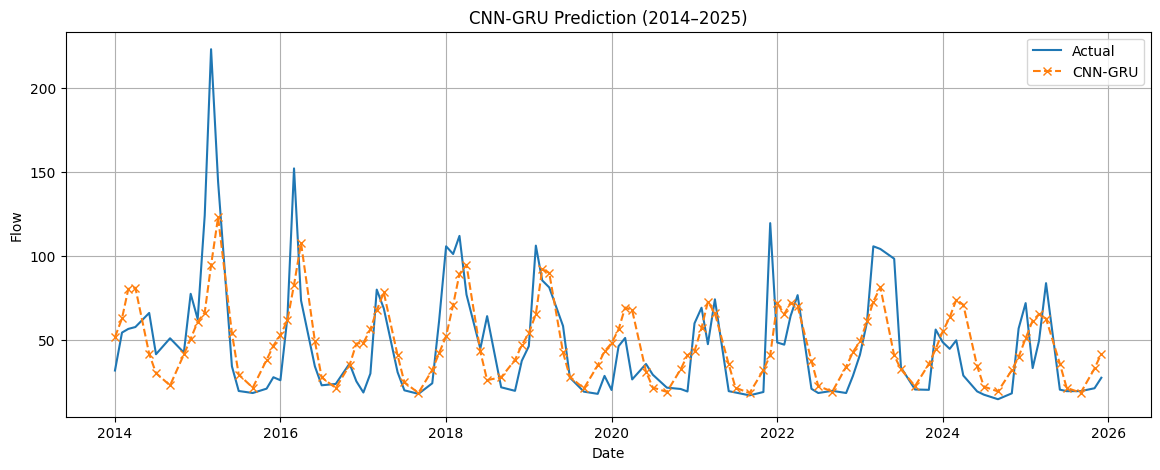

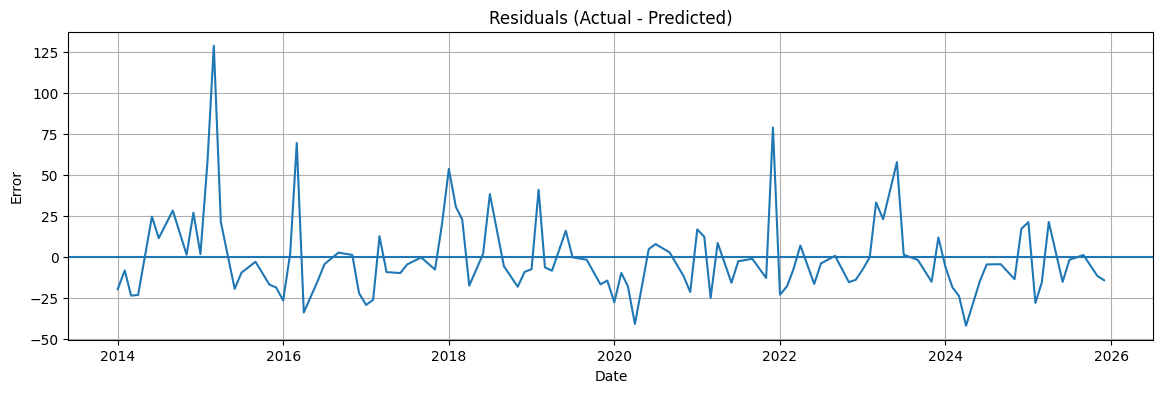

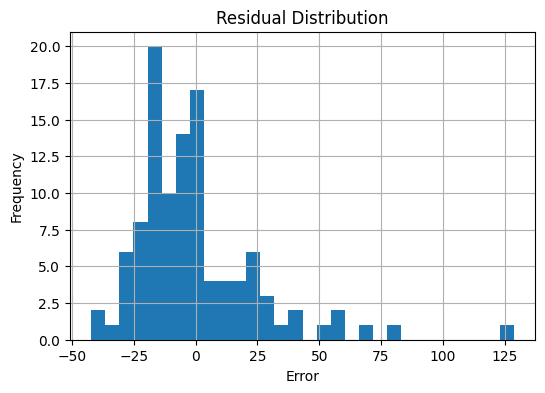

In [23]:
cnn_gru_model, cnn_gru_scaler = train_cnn_gru(X_train, y_train)
y_pred_cnn_gru, metrics = test_cnn_gru(cnn_gru_model, cnn_gru_scaler, data)